In [1]:
jb hj

ModuleNotFoundError: No module named 'seaborn'

In [2]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [3]:
import seaborn as sns

penguins = sns.load_dataset("penguins")


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('penguins
print(df.head())
custom_palette = {
    "Gentoo": "#FF5733",  
    "Adelie": "#D3D3D3",  
    "Chinstrap": "#D3D3D3",  
}

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


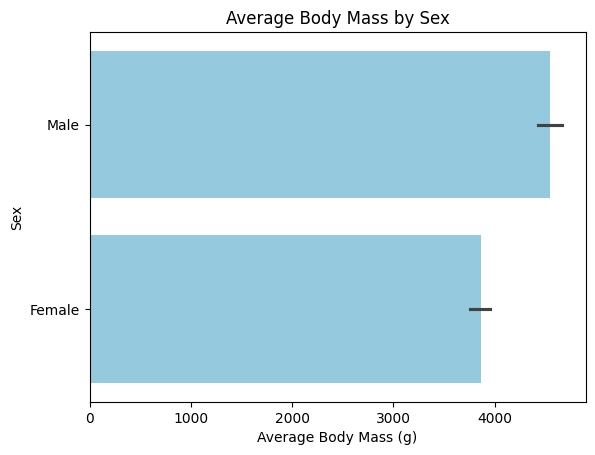

In [61]:
ax = sns.barplot(data=df, x="body_mass_g", y="sex", estimator="mean",  color="skyblue")

plt.xlabel("Average Body Mass (g)")
plt.ylabel("Sex")
plt.title("Average Body Mass by Sex")


plt.show()

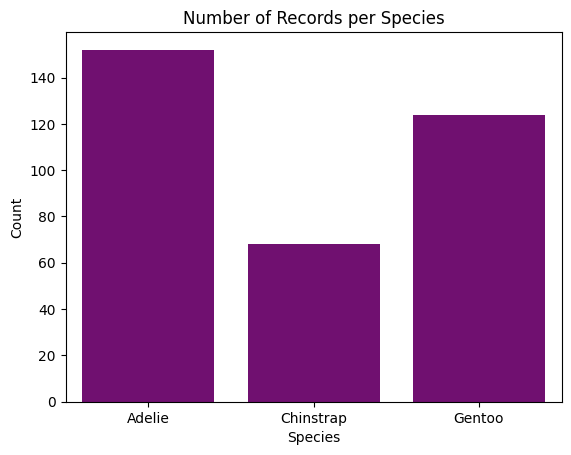

In [62]:
ax = sns.countplot(data=df, x="species", color='purple')

plt.xlabel("Species")
plt.ylabel("Count")
plt.title("Number of Records per Species")

plt.show()

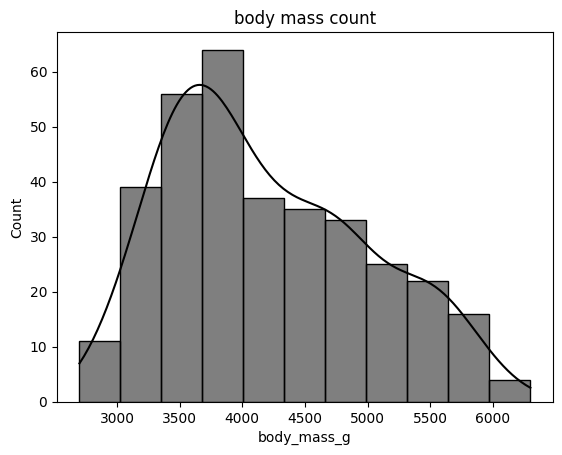

In [68]:
sns.histplot(data=df,x='body_mass_g',kde=True, color='black')
plt.title('body mass count')
plt.show()

<AxesSubplot: xlabel='body_mass_g', ylabel='species'>

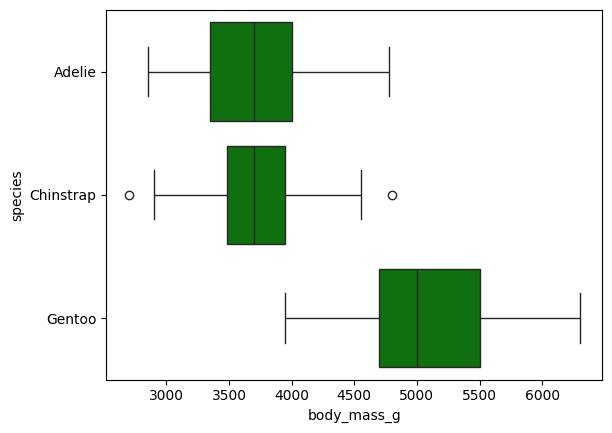

In [69]:
sns.boxplot(data=df, x="body_mass_g", y="species",color='green')


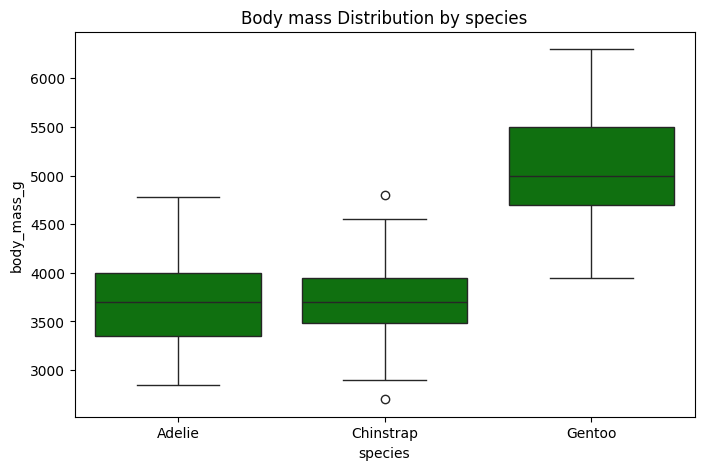

In [71]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x='species' , y='body_mass_g',color='green')
plt.title('Body mass Distribution by species')
plt.show()


In [24]:
Q1 = df['body_mass_g'].quantile(0.25)
Q3 = df['body_mass_g'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['body_mass_g'] < lower) | (df['body_mass_g'] > upper)]
print(len(outliers))

0


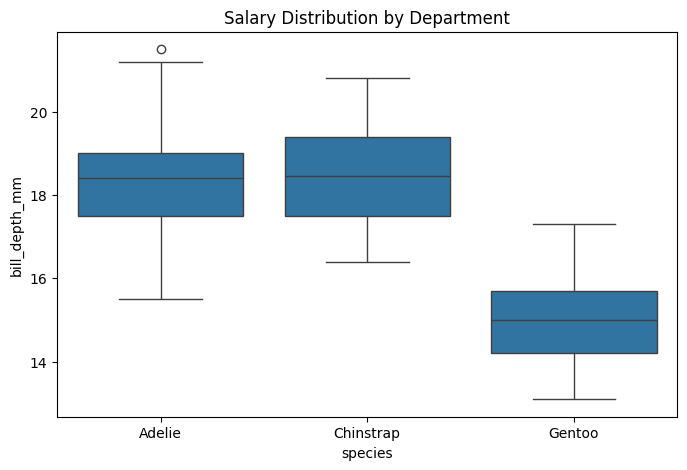

In [25]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='species', y='bill_depth_mm')
plt.title('Salary Distribution by Department')
plt.show()


In [29]:
from scipy import stats
df['zscore'] = stats.zscore(df['body_mass_g'])
outliers_z = df[df['zscore'].abs() > 3]
print(len(outliers_z))

0


In [65]:
df['bill_length_mm'] = pd.to_numeric(df['bill_length_mm'], errors='coerce')

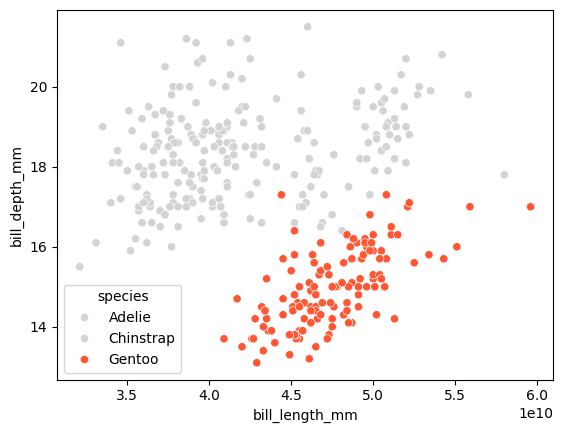

In [66]:
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette=custom_palette,  
)


plt.show()

In [73]:
df_sorted = df.sort_values('bill_length_mm')


df_sorted['bill_length_bin'] = pd.cut(df_sorted['bill_length_mm'], bins=10)


trend = df_sorted.groupby('bill_length_bin', observed=True)['body_mass_g'].mean().reset_index()
trend['bill_length_bin'] = trend['bill_length_bin'].astype(str)  # for clean x-axis labels



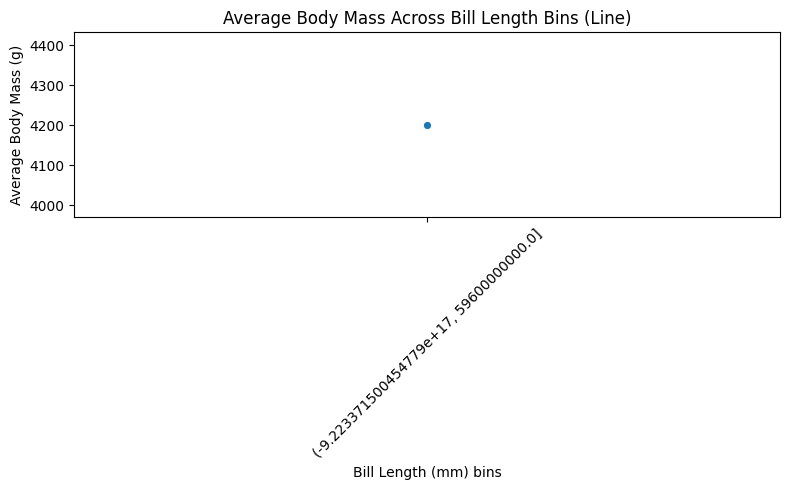

In [74]:
plt.figure(figsize=(8,5))
sns.lineplot(data=trend, x='bill_length_bin', y='body_mass_g', marker='o')
plt.xticks(rotation=45)
plt.xlabel("Bill Length (mm) bins")
plt.ylabel("Average Body Mass (g)")
plt.title("Average Body Mass Across Bill Length Bins (Line)")
plt.tight_layout()
plt.show()

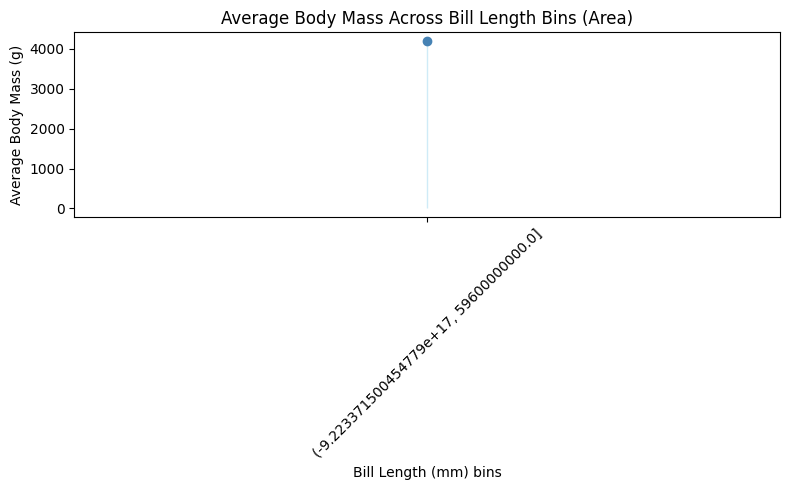

In [75]:
plt.figure(figsize=(8,5))
plt.fill_between(trend['bill_length_bin'], trend['body_mass_g'], alpha=0.4, color='skyblue')
plt.plot(trend['bill_length_bin'], trend['body_mass_g'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.xlabel("Bill Length (mm) bins")
plt.ylabel("Average Body Mass (g)")
plt.title("Average Body Mass Across Bill Length Bins (Area)")
plt.tight_layout()
plt.show()


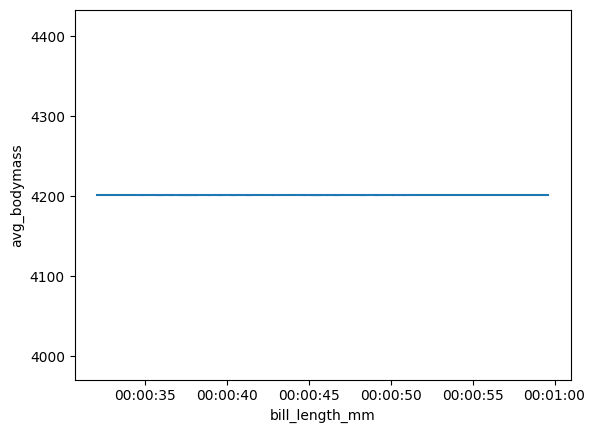

In [59]:
sns.lineplot(x='bill_length_mm', y='avg_bodymass', data=df)

plt.show()

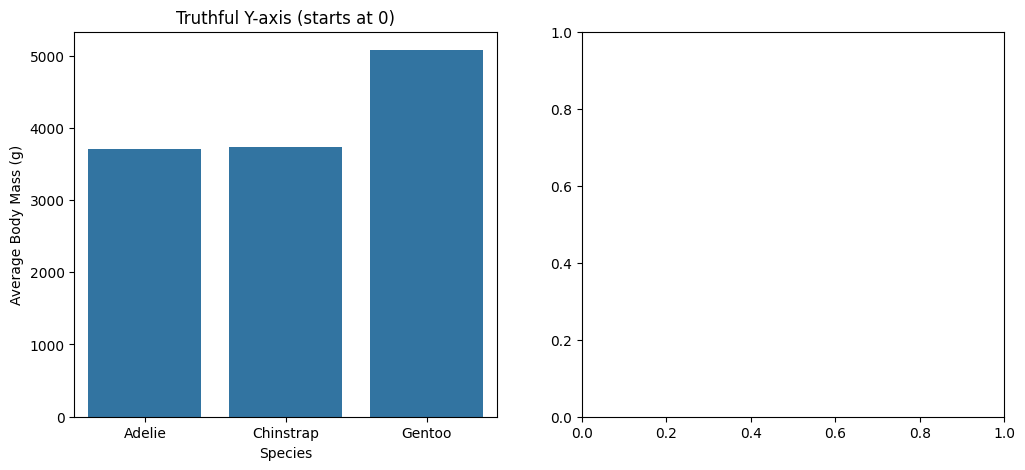

In [78]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x="species", y="body_mass_g", ax=axes[0], errorbar=None)
axes[0].set_ylim(bottom=0)
axes[0].set_xlabel("Species")
axes[0].set_ylabel("Average Body Mass (g)")
axes[0].set_title("Truthful Y-axis (starts at 0)")

plt.show()